In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

# load
meta = pd.read_csv("final_meta.csv")
meta.columns = meta.columns.str.strip()

# parse multi_label safely
meta["multi_label"] = meta["multi_label"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

labels_array = np.array(meta["multi_label"].tolist())

# your class names (aligned with model outputs)
label_map = [
    "Scream", "Crying", "Gunshot", "Glass",
    "Alarm", "Explosion", "Shout", "Siren"
]

print("Samples:", len(meta), "| Classes:", labels_array.shape[1])

Samples: 12568 | Classes: 8


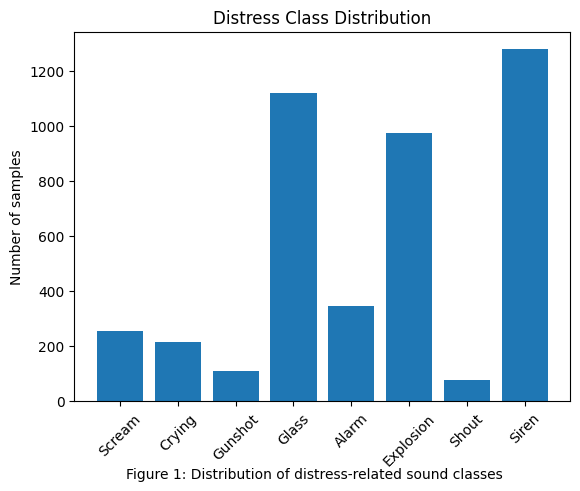

In [16]:
class_counts = labels_array.sum(axis=0)

plt.figure()
plt.bar(label_map, class_counts)
plt.xticks(rotation=45)
plt.ylabel("Number of samples")
plt.title("Distress Class Distribution")

plt.figtext(0.5, -0.05,
            "Figure 1: Distribution of distress-related sound classes",
            ha="center", fontsize=10)

plt.show()

In [3]:
import numpy as np

labels_array = np.array(meta["multi_label"].tolist())

# 1 = non-distress, 0 = distress
meta["non_distress"] = (labels_array.sum(axis=1) == 0).astype(int)

In [4]:
distress_count = (meta["non_distress"] == 0).sum()
non_distress_count = (meta["non_distress"] == 1).sum()

print("Distress samples:", distress_count)
print("Non-distress samples:", non_distress_count)

Distress samples: 3909
Non-distress samples: 8659


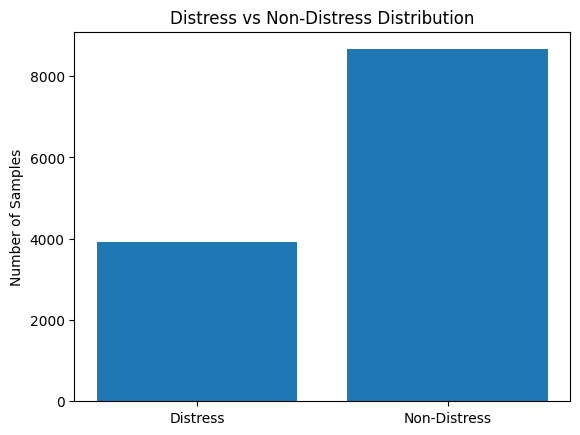

In [5]:
import matplotlib.pyplot as plt

labels = ["Distress", "Non-Distress"]
counts = [distress_count, non_distress_count]

plt.figure()
plt.bar(labels, counts)
plt.title("Distress vs Non-Distress Distribution")
plt.ylabel("Number of Samples")
plt.show()

In [6]:
total = len(meta)

print("Distress %:", (distress_count / total) * 100)
print("Non-distress %:", (non_distress_count / total) * 100)

Distress %: 31.102800763844684
Non-distress %: 68.89719923615532


In [7]:
for split in ["train", "val"]:
    sub = meta[meta["split"] == split]
    
    labels_array = np.array(sub["multi_label"].tolist())
    non_distress = (labels_array.sum(axis=1) == 0).sum()
    distress = len(sub) - non_distress
    
    print(f"{split} → Distress: {distress}, Non-distress: {non_distress}")

train → Distress: 3461, Non-distress: 7678
val → Distress: 448, Non-distress: 981


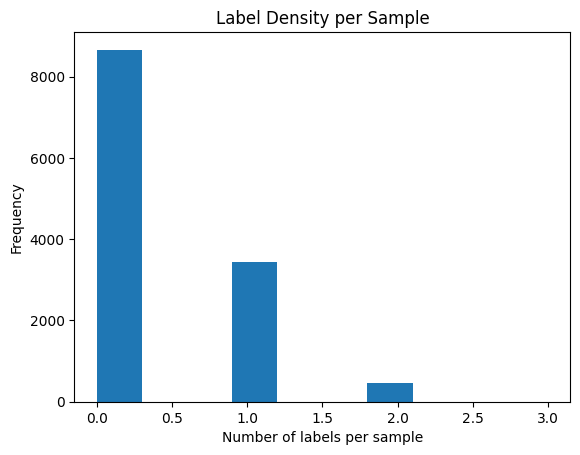

Average labels per sample: 0.3485041374920433
Max labels in a sample: 3


In [16]:
labels_per_sample = labels_array.sum(axis=1)

plt.figure()
plt.hist(labels_per_sample, bins=10)
plt.xlabel("Number of labels per sample")
plt.ylabel("Frequency")
plt.title("Label Density per Sample")
plt.show()

print("Average labels per sample:", labels_per_sample.mean())
print("Max labels in a sample:", labels_per_sample.max())

In [17]:
zero_count = (labels_array.sum(axis=1) == 0).sum()
print("Zero-label samples:", zero_count)
print("Percentage:", 100 * zero_count / len(meta))

Zero-label samples: 8659
Percentage: 68.89719923615532


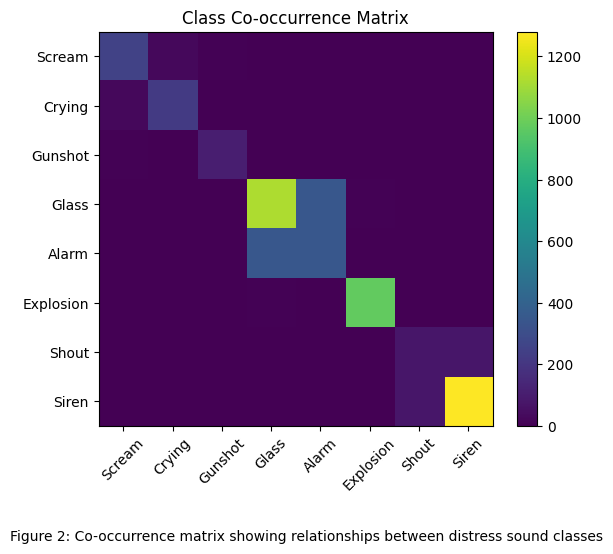

In [18]:
co_matrix = labels_array.T @ labels_array
plt.figure(figsize=(6, 5))

plt.imshow(co_matrix)
plt.colorbar()

plt.xticks(range(len(label_map)), label_map, rotation=45)
plt.yticks(range(len(label_map)), label_map)

plt.title("Class Co-occurrence Matrix")

# add caption (same style as before)
plt.figtext(
    0.5, -0.08,
    "Figure 2: Co-occurrence matrix showing relationships between distress sound classes",
    ha="center", fontsize=10
)

plt.tight_layout()
plt.show()

split
train    11139
val       1429
Name: count, dtype: int64


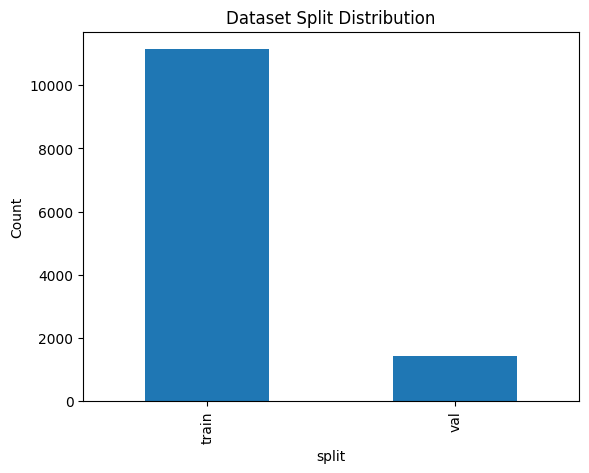

In [19]:
print(meta["split"].value_counts())

meta["split"].value_counts().plot(kind="bar", title="Dataset Split Distribution")
plt.ylabel("Count")
plt.show()

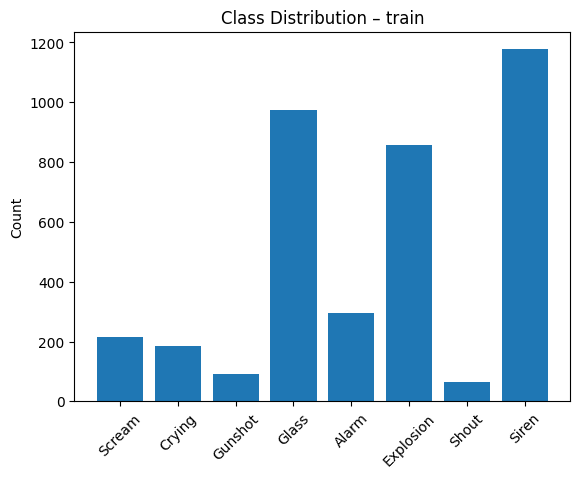

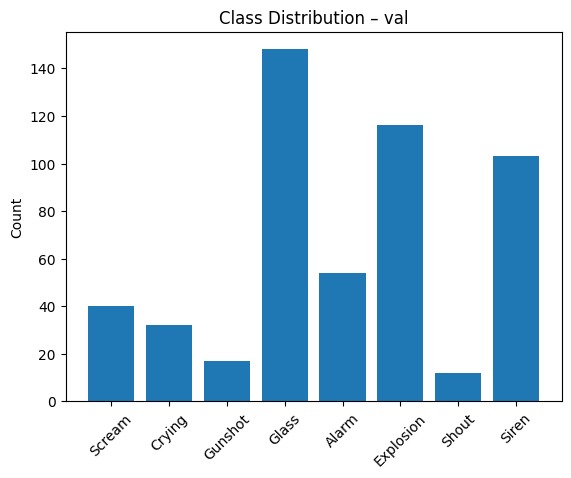

In [20]:
for sp in ["train", "val"]:
    sub = meta[meta["split"] == sp]
    arr = np.array(sub["multi_label"].tolist())
    counts = arr.sum(axis=0)

    plt.figure()
    plt.bar(label_map, counts)
    plt.xticks(rotation=45)
    plt.title(f"Class Distribution – {sp}")
    plt.ylabel("Count")
    plt.show()

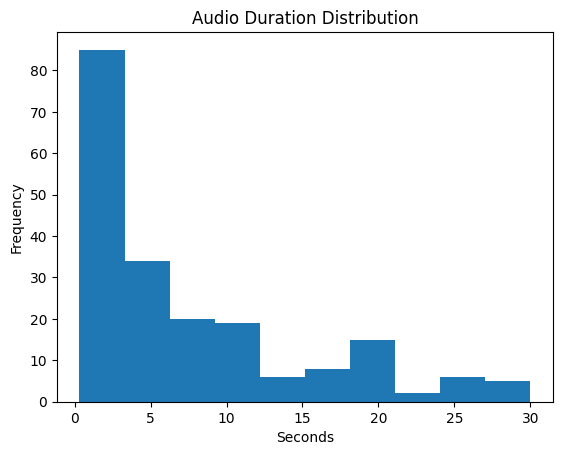

Avg duration: 7.327581875


In [21]:
import librosa, os

BASE_PATH = r"C:\Users\Amol\OneDrive\Desktop\New folder\fsd50k\FSD50K.dev_audio_16k"

lengths = []
for i in range(min(200, len(meta))):  # sample for speed
    p = os.path.join(BASE_PATH, str(meta.iloc[i]["fname"]) + ".wav")
    try:
        y, sr = librosa.load(p, sr=16000)
        lengths.append(len(y) / sr)
    except:
        pass

plt.figure()
plt.hist(lengths, bins=10)
plt.xlabel("Seconds")
plt.ylabel("Frequency")
plt.title("Audio Duration Distribution")
plt.show()

print("Avg duration:", np.mean(lengths))

NameError: name 'meta' is not defined